# The rig: recorded drives and the on-chip filter

The library's window-image tracker, run on three recorded GPS+IMU logs, and the
same filter frozen into C and run on the Nano 33 BLE Sense. Claims:

1. The adaptive window (the library default) beats the fixed window at short
   horizons on the 5 Hz drive and the 1 Hz drive; at the 10-step horizon the
   walk log does not favour it, and under dropouts the walk favours the fixed
   window at the two longer gaps. False if the fixed window matches or beats
   the adaptive one at h=2 on either driving log, or if the walk log also
   favours the adaptive window at h=10 or through its 10- and 15-sample
   dropouts.
2. The on-chip filter is cheap relative to the board's budget: state, flash
   and RAM stay well under half of it on every sketch, and a two-axis update
   costs on the order of 200 microseconds. False if any sketch exceeds half
   the board's flash or RAM, or if a two-axis update reaches a millisecond.
3. The chip's float32 output over the whole replayed drive agrees with a
   float64 replay of the identical algebra to millimetres; it disagrees with
   the library's own fixed-window `ImageFilter` at the metre scale: the
   library filter's damped update and jump test have no counterpart on the
   chip. False if the chip-vs-golden agreement is not at least two orders
   of magnitude tighter than the chip-vs-library one.

The recorded drives and the on-chip replay capture are private (`$DTFIT_RIG_DATA`,
see the setup cell's `rig_log`); a checkout without them skips those cells and
keeps this notebook's committed output. The compile logs and the on-boot
validation capture are tracked under `experiments/captures/` and always run.

In [1]:
import os
import re
import struct
import time
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

import dtfit_hardware
from dtfit_hardware import compare_real as C
from dtfit_hardware.tools import embed_lsi, make_replay
from dtfit_experimental.study import notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

ROOT = Path(dtfit_hardware.__file__).resolve().parents[2] / "experiments"
CAPTURES = ROOT / "captures"
DATA_DIR = Path(dtfit_hardware.__file__).resolve().parent / "data"


def rig_log(name):
    """Locate a private rig file: $DTFIT_RIG_DATA when set, else the
    package's own (gitignored) data/ directory. Returns None, after printing
    one line naming the missing path, when the file is absent."""
    base = Path(os.environ["DTFIT_RIG_DATA"]) if os.environ.get("DTFIT_RIG_DATA") else DATA_DIR
    path = base / name
    if not path.exists():
        print(f"private rig file missing, skipping: {path}")
        return None
    return path


DRIVES = [
    ("5 Hz drive", "drive_5hz_20260702_182933.csv"),
    ("walk", "walk_outdoor_20260701_193931.csv"),
    ("1 Hz drive", "drive_20260702_154512.csv"),
]
HORIZONS = (2,) if QUICK else (2, 3, 5, 10)
GAPS = () if QUICK else (5, 10, 15)
print(f"QUICK={QUICK}")

QUICK=False


## Window sweep: adaptive against fixed, on three recorded drives

`compare_real.sweep_rows` runs the GPS-only Legendre tracker's forecast and
dropout-coasting RMSE, motion-only, once with the image filter's window
adaptive (the library default) and once fixed at its configured cap, on each
drive: a 5 Hz car drive, a pedestrian walk logged at about 1 Hz, and a second
car drive also logged at about 1 Hz. CT-EKF and Kalman-CA, both fixed-form
recursive baselines with no window to adapt, sit beside them for scale.

In [2]:
rows = []
for label, fname in DRIVES:
    path = rig_log(fname)
    if path is None:
        continue
    for adaptive in (True, False):
        for r in C.sweep_rows(str(path), horizons=HORIZONS, gaps=GAPS,
                              adaptive_window=adaptive):
            r["drive"] = label
            r["window"] = "adaptive" if adaptive else "fixed"
            rows.append(r)
window_sweep = pd.DataFrame(rows)
window_sweep

,kind,h,gap,gps_ctrl,gyro_gated,gyro_compass,ct_ekf,kalman,compass_resid_deg,drive,window
0,forecast,2.0,NaN,1.730023,1.724937,1.841812,1.318664,1.426877,66.017185,5 Hz drive,adaptive
1,forecast,3.0,NaN,2.051854,2.055419,2.173785,1.778821,2.022237,66.017185,5 Hz drive,adaptive
2,forecast,5.0,NaN,2.862812,2.872077,3.012539,2.813580,3.454194,66.017185,5 Hz drive,adaptive
3,forecast,10.0,NaN,5.428704,5.472368,5.639769,6.184889,8.622791,66.017185,5 Hz drive,adaptive
4,coast,NaN,5.0,2.040582,1.913397,2.600033,1.287564,NaN,66.017185,5 Hz drive,adaptive
5,coast,NaN,10.0,3.931326,3.300411,3.131655,2.607602,NaN,66.017185,5 Hz drive,adaptive
6,coast,NaN,15.0,4.538284,4.893887,4.992418,4.344596,NaN,66.017185,5 Hz drive,adaptive
7,forecast,2.0,NaN,2.994797,3.016337,2.984139,1.318664,1.426877,66.017185,5 Hz drive,fixed
8,forecast,3.0,NaN,3.176814,3.200309,3.166898,1.778821,2.022237,66.017185,5 Hz drive,fixed
9,forecast,5.0,NaN,3.700018,3.729592,3.691397,2.813580,3.454194,66.017185,5 Hz drive,fixed


In [3]:
if window_sweep.empty:
    print("no private drive logs found, skipping the window sweep")
else:
    forecast = window_sweep[window_sweep.kind == "forecast"]
    table = forecast.pivot_table(index=["drive", "h"], columns="window",
                                 values=["gps_ctrl", "ct_ekf", "kalman"])
    print(table)

                    ct_ekf              gps_ctrl                kalman  \
window            adaptive      fixed   adaptive      fixed   adaptive   
drive      h                                                             
1 Hz drive 2.0    3.189011   3.189011  12.325379  35.335353   3.641302   
           3.0    5.014026   5.014026  15.198628  37.951295   5.930414   
           5.0    9.727068   9.727068  22.279879  45.017927  12.128439   
           10.0  27.940504  27.940504  44.900305  70.634925  37.456107   
5 Hz drive 2.0    1.318664   1.318664   1.730023   2.994797   1.426877   
           3.0    1.778821   1.778821   2.051854   3.176814   2.022237   
           5.0    2.813580   2.813580   2.862812   3.700018   3.454194   
           10.0   6.184889   6.184889   5.428704   5.727259   8.622791   
walk       2.0    5.529749   5.529749   6.776564   7.590306   6.450476   
           3.0    7.949947   7.949947   7.963133   8.379876   9.992544   
           5.0   13.287911  13.287911 

### Coasting through a dropout

The coast rows blank `gap` consecutive fixes every 80 samples past warm-up and
score each method only inside the blanked stretches, so `gap` counts samples
and not seconds: 15 samples is 3 s of the 5 Hz drive and about 15 s of either
1 Hz log. Kalman-CA is not coasted in this sweep, so its column is NaN on every
coast row.

In [4]:
if window_sweep.empty:
    print("no private drive logs found, skipping the coast table")
else:
    coasted = window_sweep[window_sweep.kind == "coast"]
    print(coasted.pivot_table(index=["drive", "gap"], columns="window",
                              values=["gps_ctrl", "ct_ekf"]))

                    ct_ekf              gps_ctrl           
window            adaptive      fixed   adaptive      fixed
drive      gap                                             
1 Hz drive 5.0    5.970282   5.970282  25.871653  33.405458
           10.0  15.848911  15.848911  39.681460  53.999343
           15.0  26.687008  26.687008  61.736975  70.779762
5 Hz drive 5.0    1.287564   1.287564   2.040582   3.438359
           10.0   2.607602   2.607602   3.931326   4.659445
           15.0   4.344596   4.344596   4.538284   6.370621
walk       5.0    2.749572   2.749572   4.318689   5.278190
           10.0  14.659680  14.659680  15.138750  14.744239
           15.0  21.861383  21.861383  21.828364  21.130382


In [5]:
if not window_sweep.empty and not QUICK:
    notebook.save_table("rig", "window_sweep", window_sweep, root=ROOT)
    print("wrote experiments/results/rig/window_sweep.csv")
elif QUICK:
    print("QUICK: skipping the CSV export")

wrote experiments/results/rig/window_sweep.csv


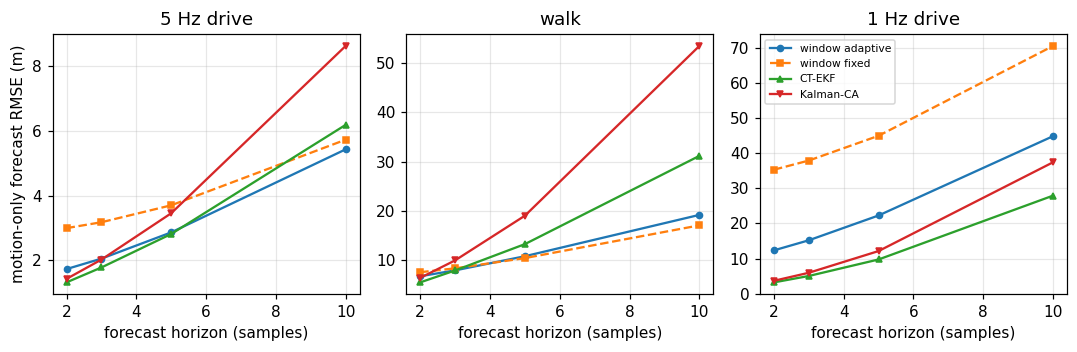

In [6]:
if not window_sweep.empty:
    fc_plot = window_sweep[window_sweep.kind == "forecast"]
    drives = [d for d, _ in DRIVES if (fc_plot.drive == d).any()]
    # CT-EKF and Kalman-CA have no window to set, so their rows repeat across
    # both window settings: one line each, taken off the adaptive rows.
    series = (("adaptive", "gps_ctrl", "o-", "window adaptive"),
              ("fixed", "gps_ctrl", "s--", "window fixed"),
              ("adaptive", "ct_ekf", "^-", "CT-EKF"),
              ("adaptive", "kalman", "v-", "Kalman-CA"))
    fig, axes = plt.subplots(1, len(drives), figsize=(3.3 * len(drives), 3.3),
                             squeeze=False)
    for ax, drive in zip(axes[0], drives):
        part = fc_plot[fc_plot.drive == drive]
        for window, column, style, label in series:
            line = part[part.window == window].sort_values("h")
            ax.plot(line.h, line[column], style, ms=4, label=label)
        ax.set_title(drive)
        ax.set_xlabel("forecast horizon (samples)")
        ax.grid(True, alpha=0.3)
    axes[0][0].set_ylabel("motion-only forecast RMSE (m)")
    axes[0][-1].legend(fontsize=7)
    fig.tight_layout()
    plt.show()

The panels above plot the forecast rows, one per drive: the two window
settings against the two fixed-form baselines.

The 5 Hz drive favours the adaptive window at every horizon measured: 1.73 m
against 2.99 m at h=2, 5.43 m against 5.73 m at h=10. The 1 Hz drive favours
it even more sharply at the short horizon, 12.33 m against 35.34 m at h=2, and
still favours it at h=10, 44.90 m against 70.63 m. The walk favours the
adaptive window at h=2 (6.78 m against 7.59 m) but not at h=10, where the
fixed window is better, 17.09 m against 19.21 m, a loss for the adaptive
window. CT-EKF and Kalman-CA, run once and
shown beside both window settings, do not win outright at every horizon. On
the 1 Hz drive they win at every horizon measured (3.19 m and 3.64 m against
the tracker's 12.33 m at h=2, widening to 27.94 m and 37.46 m against 44.90 m
at h=10). On the 5 Hz drive and the walk the picture is mixed: at h=2 both
baselines beat the tracker (1.32 m and 1.43 m against 1.73 m on the 5 Hz
drive; 5.53 m and 6.45 m against 6.78 m on the walk); at h=3 CT-EKF still
edges the tracker on both logs (1.78 m against 2.05 m on the 5 Hz drive; 7.95
m against 7.96 m on the walk, which is parity, not a win) while Kalman-CA
already trails the tracker on the walk (9.99 m); at h=5 CT-EKF keeps a narrow
lead on the 5 Hz drive (2.81 m against 2.86 m) but Kalman-CA does not (3.45
m), and on the walk the tracker beats both (10.83 m against 13.29 m and 19.05
m); at h=10 the tracker beats both baselines on both logs, 5.43 m against
6.18 m and 8.62 m on the 5 Hz drive and 19.21 m against 31.18 m and 53.47 m
on the walk.

Coasting through a dropout has the same shape and not the same verdict. The
adaptive window wins every gap on both driving logs: 2.04 m against 3.44 m at
a 5-sample gap on the 5 Hz drive and 4.54 m against 6.37 m at 15 samples,
25.87 m against 33.41 m and 61.74 m against 70.78 m on the 1 Hz drive. It
wins the walk's 5-sample gap too, 4.32 m against 5.28 m, and then loses the
two longer ones: 15.14 m against 14.74 m at 10 samples, 21.83 m against
21.13 m at 15. Those are two further losses for the adaptive window, beside
the walk's h=10 forecast loss. CT-EKF, which has no window to adapt, coasts
better than both window settings at every gap of both driving logs, by a wide
margin on the 1 Hz drive (5.97 m against 25.87 m at 5 samples, 26.69 m against
61.74 m at 15) and by a narrowing one on the 5 Hz drive (1.29 m against 2.04 m
at 5 samples, 4.34 m against 4.54 m at 15). On the walk it wins the 5-sample
gap outright (2.75 m against 4.32 m), wins the 10-sample gap narrowly (14.66 m
against 14.74 m and 15.14 m) and loses the 15-sample gap to both window
settings, 21.86 m against 21.13 m and 21.83 m, which against the adaptive
window is parity rather than a win for the tracker.

In [7]:
if window_sweep.empty:
    print("no drive rows in the sweep, skipping the checks")
else:
    fc = window_sweep[window_sweep.kind == "forecast"]
    co = window_sweep[window_sweep.kind == "coast"]

    def val(frame, drive, key, value, window, column="gps_ctrl"):
        row = frame[(frame.drive == drive) & (frame[key] == value)
                    & (frame.window == window)]
        return float(row[column].iloc[0])

    checked = []
    for drive in ("5 Hz drive", "1 Hz drive"):
        if not (fc.drive == drive).any():
            continue
        # fails if the fixed window matches or beats the adaptive one on a
        # driving log at the short horizon
        assert val(fc, drive, "h", 2, "adaptive") < val(fc, drive, "h", 2, "fixed"), drive
        for gap in GAPS:
            # fails if the fixed window coasts a driving log as well as the
            # adaptive one at any gap
            assert val(co, drive, "gap", gap, "adaptive") < val(
                co, drive, "gap", gap, "fixed"), (drive, gap)
            # fails if either window setting coasts a driving log better than
            # CT-EKF at any gap
            ekf = val(co, drive, "gap", gap, "adaptive", column="ct_ekf")
            for window in ("adaptive", "fixed"):
                assert ekf < val(co, drive, "gap", gap, window), (drive, gap, window)
        checked.append(drive)

    if (fc.drive == "walk").any():
        if 10 in HORIZONS:
            # fails if the walk also favours the adaptive window at h=10
            assert val(fc, "walk", "h", 10, "adaptive") > val(fc, "walk", "h", 10, "fixed")
        if 5 in GAPS:
            # fails if the walk's shortest dropout stops favouring the
            # adaptive window
            assert val(co, "walk", "gap", 5, "adaptive") < val(co, "walk", "gap", 5, "fixed")
        for gap in (g for g in (10, 15) if g in GAPS):
            # fails if the adaptive window also wins the walk's longer dropouts
            assert val(co, "walk", "gap", gap, "adaptive") > val(co, "walk", "gap", gap, "fixed")
        if 15 in GAPS:
            # fails if CT-EKF also wins the walk's longest dropout
            assert val(co, "walk", "gap", 15, "adaptive", column="ct_ekf") > val(
                co, "walk", "gap", 15, "fixed")
        checked.append("walk")

    print(f"checked {', '.join(checked)}: the adaptive window wins h=2 on both "
          "driving logs and every dropout on them, loses the walk at h=10 and "
          "at the 10- and 15-sample dropouts, and CT-EKF coasts better than "
          "either window setting on the drives but not on the walk's longest "
          "dropout")

checked 5 Hz drive, 1 Hz drive, walk: the adaptive window wins h=2 on both driving logs and every dropout on them, loses the walk at h=10 and at the 10- and 15-sample dropouts, and CT-EKF coasts better than either window setting on the drives but not on the walk's longest dropout


## On-chip cost and memory, from the tracked captures

Flash and RAM are read from the three compile logs under
`experiments/captures/`. Per-update cost and state size come from
`rig_onboard_boot.txt` (the single-axis on-boot self-test, tracked) and from
the replay capture over the whole recorded 5 Hz drive (private, guarded by
`rig_log`); `nano_lsi_log`, the sketch the rig actually runs, has no tracked
runtime capture, so its cost columns are left blank.

In [8]:
def parse_compile(path):
    text = path.read_text()
    flash = re.search(r"Sketch uses (\d+) bytes \((\d+)%\)", text)
    ram = re.search(r"Global variables use (\d+) bytes \((\d+)%\)", text)
    return int(flash.group(1)), int(flash.group(2)), int(ram.group(1)), int(ram.group(2))


def parse_capture(path):
    text = path.read_text()
    cost = re.search(r"([\d.]+) us avg, ([\d.]+) us max", text)
    state = re.search(r"state(?: footprint)?[=:]?\s*=?\s*(\d+) bytes", text)
    updates = re.search(r"updates=(\d+)", text)
    return (float(cost.group(1)), float(cost.group(2)),
            int(state.group(1)), int(updates.group(1)))


rows = []
onboard_flash = parse_compile(CAPTURES / "compile_nano_lsi_onboard.log")
onboard_avg, onboard_max, onboard_state, onboard_n = parse_capture(
    CAPTURES / "rig_onboard_boot.txt")
rows.append(dict(sketch="nano_lsi_onboard", flash_bytes=onboard_flash[0],
                 flash_pct=onboard_flash[1], ram_bytes=onboard_flash[2],
                 ram_pct=onboard_flash[3], state_bytes=onboard_state,
                 avg_us=onboard_avg, max_us=onboard_max, updates=onboard_n))

replay_flash = parse_compile(CAPTURES / "compile_replay.log")
replay_path = rig_log("rig_replay_drive5hz.txt")
if replay_path is not None:
    replay_avg, replay_max, replay_state, replay_n = parse_capture(replay_path)
else:
    replay_avg = replay_max = replay_state = replay_n = float("nan")
rows.append(dict(sketch="nano_lsi_replay", flash_bytes=replay_flash[0],
                 flash_pct=replay_flash[1], ram_bytes=replay_flash[2],
                 ram_pct=replay_flash[3], state_bytes=replay_state,
                 avg_us=replay_avg, max_us=replay_max, updates=replay_n))

log_flash = parse_compile(CAPTURES / "compile_nano_lsi_log.log")
rows.append(dict(sketch="nano_lsi_log", flash_bytes=log_flash[0],
                 flash_pct=log_flash[1], ram_bytes=log_flash[2],
                 ram_pct=log_flash[3], state_bytes=float("nan"),
                 avg_us=float("nan"), max_us=float("nan"), updates=float("nan")))

onchip_cost = pd.DataFrame(rows)
onchip_cost

,sketch,flash_bytes,flash_pct,ram_bytes,ram_pct,state_bytes,avg_us,max_us,updates
0,nano_lsi_onboard,91760,9,44928,17,152.0,104.32,139.27,93.0
1,nano_lsi_replay,162224,16,44856,17,304.0,181.92,235.03,6103.0
2,nano_lsi_log,392856,39,74120,28,NaN,NaN,NaN,NaN


In [9]:
# fails if any sketch crosses half the board's flash or RAM, or if a
# two-axis update reaches a millisecond
assert (onchip_cost.flash_pct < 50).all()
assert (onchip_cost.ram_pct < 50).all()
max_us_measured = onchip_cost.max_us.dropna()
assert (max_us_measured < 1000).all()
print(f"flash {onchip_cost.flash_pct.min()}-{onchip_cost.flash_pct.max()}%, "
      f"RAM {onchip_cost.ram_pct.min()}-{onchip_cost.ram_pct.max()}%, "
      f"worst measured update {max_us_measured.max():.1f} us: "
      "comfortably inside the board's budget")

flash 9-39%, RAM 17-28%, worst measured update 235.0 us: comfortably inside the board's budget


In [10]:
if not QUICK:
    notebook.save_table("rig", "onchip_cost", onchip_cost, root=ROOT)
    print("wrote experiments/results/rig/onchip_cost.csv")
else:
    print("QUICK: skipping the CSV export")

wrote experiments/results/rig/onchip_cost.csv


`nano_lsi_onboard`, one axis, uses 9% of flash and 17% of RAM, 152 bytes of
state, and averages 104.3 us a two-parameter update (139.3 us at most) over
its 93-update on-boot self-test. `nano_lsi_replay`, two axes run the way
`nano_lsi_log` feeds them, uses 16% of flash (the recorded drive's own data
adds most of the difference from onboard's 9%) and the same 17% of RAM, 304
bytes of state, and averages 181.9 us an update (235.0 us at most) over the
6103 two-axis updates of the whole replayed drive. `nano_lsi_log`, the sketch
the rig actually runs, uses 39% of flash and 28% of RAM for the full
GPS+IMU+SD+BLE stack; it has no tracked per-update capture, so its cost stays
unmeasured here. All three sit comfortably inside the board's budget; a
two-axis update running at 235.0 us at most is nowhere near a millisecond.

## Float32 agreement over the whole replayed drive

The replay sketch plays the 5 Hz drive's fixes back through two on-chip
filters, one per axis, the way `nano_lsi_log` feeds them (no zero-velocity
update). `make_replay.from_log` reduces the same drive to the identical
float32 `(t, e, n)` vector the replay capture was recorded against;
`embed_lsi.golden_run` is the float64 reference for the same fixed-window
algebra, and `embed_lsi.dtfit_run` is the library's `ImageFilter` restricted
to the same window and order, which does carry the damped update and jump
test the chip does not.

In [11]:
replay_path = rig_log("rig_replay_drive5hz.txt")
drive_path = rig_log("drive_5hz_20260702_182933.csv")
float32_agreement = pd.DataFrame()
if replay_path is not None and drive_path is not None:
    t, e, n = make_replay.from_log(str(drive_path))
    t, e, n = t.astype(float), e.astype(float), n.astype(float)

    lines = [ln.split() for ln in replay_path.read_text().splitlines()
             if ln.startswith("R ")]
    idx = np.array([int(ln[1]) for ln in lines])
    chip = np.array([[struct.unpack(">f", bytes.fromhex(h))[0] for h in ln[2:6]]
                     for ln in lines])
    assert np.array_equal(idx, np.arange(embed_lsi.W - 1, t.size)), (
        "replay capture is missing or reordering updates")
    print(f"{idx.size} two-axis updates over {t[-1] - t[0]:.1f} s of drive")

    z = np.zeros(embed_lsi.N)
    golden_e, golden_n = embed_lsi.golden_run(t, e, z), embed_lsi.golden_run(t, n, z)
    lib_e, lib_n = embed_lsi.dtfit_run(t, e, z), embed_lsi.dtfit_run(t, n, z)

    def pos(p, tt):
        return p[:, 0] + p[:, 1] * tt

    tt = t[idx]
    rows = []
    for ref, (rE, rN) in (("float64 golden", (golden_e, golden_n)),
                          ("dtfit.ImageFilter", (lib_e, lib_n))):
        dE = pos(chip[:, 0:2], tt) - pos(rE[idx], tt)
        dN = pos(chip[:, 2:4], tt) - pos(rN[idx], tt)
        d = np.hypot(dE, dN)
        dv = np.hypot(chip[:, 1] - rE[idx, 1], chip[:, 3] - rN[idx, 1])
        rows.append(dict(reference=ref, max_m=float(d.max()),
                         median_m=float(np.median(d)),
                         p99_m=float(np.percentile(d, 99)),
                         max_velocity_ms=float(dv.max())))
    float32_agreement = pd.DataFrame(rows)
float32_agreement

6103 two-axis updates over 1280.9 s of drive


,reference,max_m,median_m,p99_m,max_velocity_ms
0,float64 golden,0.006209,0.000824,0.005336,0.003922
1,dtfit.ImageFilter,6.188560,0.017419,6.044831,4.183955


In [12]:
if not float32_agreement.empty and not QUICK:
    notebook.save_table("rig", "float32_agreement", float32_agreement, root=ROOT)
    print("wrote experiments/results/rig/float32_agreement.csv")
elif QUICK:
    print("QUICK: skipping the CSV export")
else:
    print("no private replay capture, skipping the float32 agreement export")

wrote experiments/results/rig/float32_agreement.csv


Against the float64 golden run of the identical fixed-window algebra the
chip's float32 position holds to 6.2 mm at the worst over the whole 1280.9 s
drive, 0.8 mm at the median and 5.3 mm at the 99th percentile, with 3.9 mm/s
in velocity: that is float32 rounding. Against the library's own
`ImageFilter` restricted to the same window the chip's position disagrees at
the metre scale, 6.2 m at the worst and 6.0 m at the 99th percentile, though
still only 1.7 cm at the median, so the disagreement sits in a few stretches
of the drive. The two differ in algorithm, not in arithmetic: the library
filter's damped-step guard and single-sample jump test have no counterpart
in the frozen C hot path.

In [13]:
if not float32_agreement.empty:
    golden = float32_agreement[float32_agreement.reference == "float64 golden"].iloc[0]
    library = float32_agreement[float32_agreement.reference == "dtfit.ImageFilter"].iloc[0]
    # fails if the chip-vs-golden agreement is not at least two orders of
    # magnitude tighter than the chip-vs-library one
    assert golden.max_m * 100 < library.max_m
    print(f"chip vs golden max {golden.max_m * 1000:.1f} mm; "
          f"chip vs library max {library.max_m:.1f} m "
          f"({library.max_m / golden.max_m:.0f}x looser)")

chip vs golden max 6.2 mm; chip vs library max 6.2 m (997x looser)


## Procedure: flashing and capturing

The sketches are compiled from a Windows-side copy of the sketch directory
(the Arduino CLI used here does not take a WSL path) and uploaded over USB to
a Nano 33 BLE Sense on its serial port. An upload is gated on the compile's
exit status: uploading after a failed build leaves the board in its
bootloader on a different serial port, and the next upload silently targets
that port instead of the flashed one. The serial output is captured to a text
file for the duration of the run (the on-boot self-test for `nano_lsi_onboard`
and `nano_lsi_replay`, the live GPS+IMU stream for `nano_lsi_log`) and that
capture is what this notebook and `tools/make_replay.py` read back, under
`$DTFIT_RIG_DATA` or the package's own `data/` directory. The tracked captures
under `experiments/captures/` are copies of these files with any recorded
trajectory stripped out; the private ones stay in `$DTFIT_RIG_DATA` and are
never committed.

## Findings and limits

The adaptive window wins the two driving logs outright and wins the walk at
the short horizon, but loses to the fixed window on the walk at h=10: that is
the one forecast case measured here where letting the window grow costs more
than it buys. Coasting
repeats it: the adaptive window wins every dropout on both driving logs and
the walk's 5-sample dropout, and loses the walk's 10- and 15-sample dropouts,
15.14 m against 14.74 m and 21.83 m against 21.13 m. CT-EKF and Kalman-CA,
which see the same fixes but never adapt a window, beat the GPS-only Legendre
tracker outright on the 1 Hz drive at every horizon; on the 5 Hz drive and the
walk they only win at the shortest horizons (h=2 on both logs, h=3 on the 5 Hz
drive), CT-EKF keeps a narrow edge through h=5 on the 5 Hz drive, and past
that the tracker wins outright: 5.43 m against 6.18 m and 8.62 m at h=10 on
the 5 Hz drive, 10.83 m against 13.29 m and 19.05 m at h=5 on the walk, and
19.21 m against 31.18 m and 53.47 m at h=10 on the walk. The walk's h=3
result, 7.95 m against 7.96 m, is parity rather than a baseline win. Under
dropouts the baseline keeps more: CT-EKF coasts better than either window
setting at every gap of both driving logs and at the walk's two shorter gaps,
and only at the walk's 15-sample gap does it fall to 21.86 m against the
adaptive window's 21.83 m, which is parity, and behind the fixed window's
21.13 m.

The on-chip filter is cheap: flash use ranges from 9% to 39% and RAM from 17%
to 28% of the board's budget across the three sketches, low-hundreds of
microseconds an update, comfortably inside the board's budget (well under
half of it) on every sketch that was compiled. Its float32 output agrees with
a float64 replay of the same algebra to millimetres over a full drive, which
is the precision of the chip's arithmetic; the metre-scale gap against the
library's own filter is the damped-step guard and jump test the chip does
not run.

Limits: three recorded drives, one board, one frozen configuration (window 15,
Legendre order 5, a two-parameter per-axis model); the walk and the 1 Hz drive
share a nominal 1 Hz fix rate but differ in motion, so "1 Hz" here names two
different logs, not one controlled variable. The float32 agreement section
runs only over the 5 Hz drive, the one drive with a private replay capture.
No absolute ground truth exists for any of the three logs; the RMSE numbers
above are the forecast-against-later-fix and coast-against-held-out-fix
proxies `compare_real` documents, not error against a surveyed truth.

In [14]:
print(notebook.provenance(STARTED))

2026-09-20 commit f8c253b dtfit 0.4.0 dtfit-experimental 0.1.0 275.8s
